# Homework 4: Change Detection

For this programming assignment, you will be experimenting with a pixel-level labeling method for the task of foreground detection using a subset of the [changedetection.net](http://jacarini.dinf.usherbrooke.ca/) dataset.  Most approaches to this problem use an unsupervised approach, in which you first learn what is normal for every pixel and then classify new pixels as normal (background) or abnormal (foreground).  We take a supervised learning approach using a convolutional neural network. We will be implementing this in PyTorch.

**What you will do:**
1. Train a provided baseline model under three different class-weight settings and compare the results.
2. Design two custom CNN architectures of your own.
3. Experiment with hyperparameters, train your models, and report the best F1 scores achieved.

> **Environment:** This assignment requires PyTorch with GPU support. We recommend [Google Colab](https://colab.research.google.com/) (free GPU runtime).

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


While not required, you can upload your data to your Google Drive, which will make it permanent. That way you will not need to upload the data everytime you restart your session.

Using `!` you can use terminal commands such as `!ls` or `!pwd` to find out the path to your data. Your Google Drive will have the path `./drive/MyDrive`.

Set `data_dir` variable to the appropriate path as it will be used to access the data throughout the rest of the notebook.

In [32]:
# !ls /content/drive/MyDrive/WashU/courses/26spring/CSE5509_computer_version/
# %cd /content/drive/MyDrive/WashU/courses/26spring/CSE5509_computer_version/
# !pwd
!ls

data  dataset.py  __pycache__


In [27]:
if 'google.colab' in str(get_ipython()):
    !pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 67.2 MB/s eta 0:00:00


In [28]:
import numpy as np
import json
import os
import torch
from torchmetrics.classification import MulticlassRecall, MulticlassPrecision
from tqdm import tqdm
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import pandas as pd

from typing import List, Tuple, Dict

In [29]:
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")

device = get_device()

print(f"Using torch device type: {device}")

Using torch device type: cuda


### Dataset Creation
Create a dataset that allows us to read the image and appropriate labels from the data directory

In [30]:
from dataset import MyDataset

In [31]:
def get_dataloaders(data_dir, batch_size=32, num_workers=2):
  #define train and test datasets
  train_data = MyDataset(data_dir)
  test_data = MyDataset(data_dir, train=False)
  test_data, valid_data = torch.utils.data.random_split(test_data, [0.5,0.5])
  #define train and test dataloaders
  train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=False)
  test_dataloader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=num_workers, pin_memory=False, drop_last=True)
  valid_dataloader = DataLoader(valid_data, batch_size=32, shuffle=True, num_workers=num_workers, pin_memory=False, drop_last=True)

  return train_dataloader, test_dataloader, valid_dataloader

In [33]:
# Set the data directory and create your dataloaders
data_dir = './data/'
batch_size = 6
num_workers = 2
train_dataloader, test_dataloader, valid_dataloader = get_dataloaders(data_dir, batch_size, num_workers)

print(f"Train: {len(train_dataloader.dataset)} images, "
      f"Test: {len(test_dataloader.dataset)} images, "
      f"Val: {len(valid_dataloader.dataset)} images")


Train: 1561 images, Test: 151 images, Val: 150 images


### Visualizing the Data
Once your dataloaders are ready, we can visualize our data. The code block plots a couple of examples from the training set. The left column shows your input and the right column shows the labels.

The labels only have three unique pixel values. The yellow pixels represent foreground, the dark pixels represent background, and the green pixels represent ignore classes.

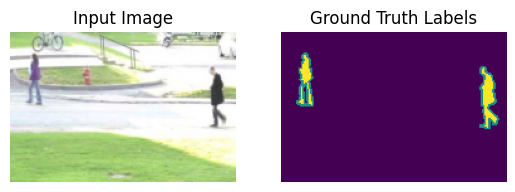

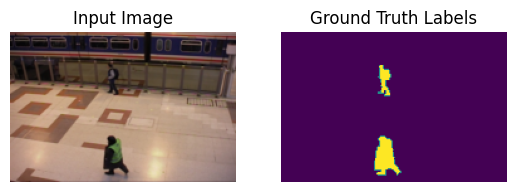

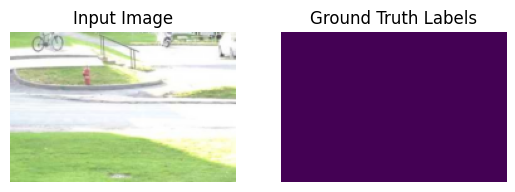

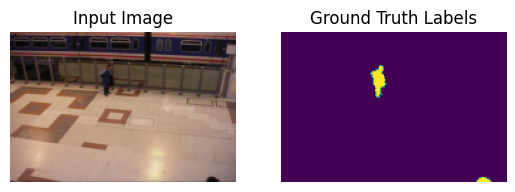

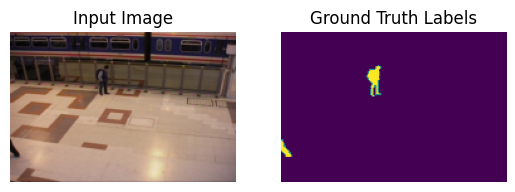

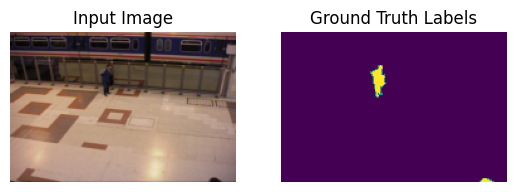

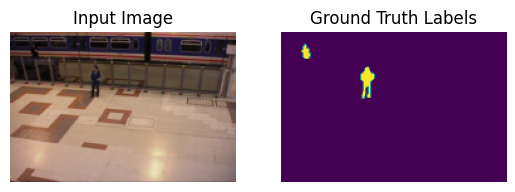

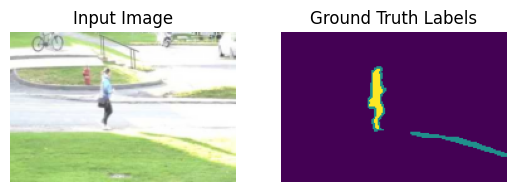

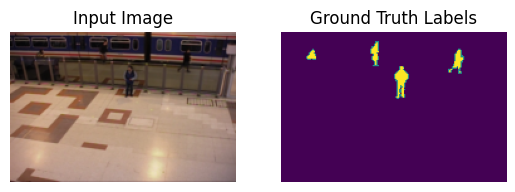

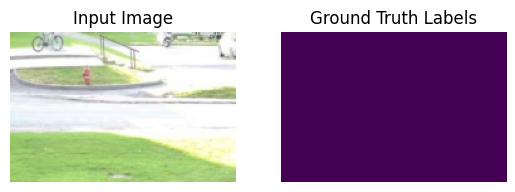

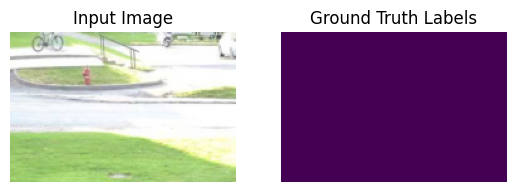

In [34]:
def visualize_data(dataloader):
  for index, (ims, labels) in enumerate(dataloader):
      labels = torch.permute(labels, (0,2,3,1))
      ims = torch.permute(ims, (0,2,3,1)).cpu()
      plt.figure(1)
      plt.clf()

      plt.subplot(1,2,1)
      plt.imshow(ims[0,:,:,:])
      plt.title('Input Image')
      plt.axis('off')

      plt.subplot(1,2,2)
      plt.imshow(labels[0,:,:,:].squeeze(),clim=(0.0,2.0))
      plt.title('Ground Truth Labels')
      plt.axis('off')

      plt.pause(.1)

      if index == 10:
          break

visualize_data(train_dataloader)

### Metrics
We will define three functions in this section: **precision**, **recall**, and **f1**. These metrics will allow us to evaluate the efficacy of our model.

In [35]:
def precision(y_true, y_pred):
  y_pred = torch.argmax(y_pred, dim=1, keepdim=True)
  prec = MulticlassPrecision(average='macro', num_classes=3, ignore_index=1).to(device)
  batch_precision = prec(y_true, y_pred)
  return batch_precision

def recall(y_true, y_pred):
  y_pred = torch.argmax(y_pred, dim=1, keepdim=True)
  rec = MulticlassRecall(average='macro', num_classes=3, ignore_index=1).to(device)
  batch_precision = rec(y_true, y_pred)
  return batch_precision

def f_measure(y_true, y_pred):
  p = precision(y_true, y_pred)
  r = recall(y_true, y_pred)
  fmeasure = 2*(p * r)/(p + r + 1e-7)
  return fmeasure

Run the sanity check below to verify the metrics work. You should see ~`tensor(0.2674)` printed.

In [36]:
# Sanity check — verify metrics are working
torch.manual_seed(42)
y_pred = torch.randn(3, 3, 120, 180).to(device)
y_true = torch.randint(0, 3, size=(3, 1, 120, 180)).to(device)
print(f_measure(y_true, y_pred))

tensor(0.2674, device='cuda:0')


# Dealing With Class Imbalance

There are three classes in this task: 0) background, 1) unknown, and 2) foreground. Unfortunately, the training dataset has a "class balance" problem, meaning there are many more background pixels than foreground pixels. This can lead to a model that only predicts background. To overcome this problem, we have a special purpose loss function that enables different types of errors to be penalized differently. The default setting, is class_weights = [.25,0,1].  This means that:

Classifying a true foreground pixel as background or unknown has the highest loss.
Classifying a true background pixel as foreground or unknown has only 1/4 the penalty.
Classifying an unknown pixel results in no loss regardless of the resulting label.

Your task is to train three models:

- using the default class weight
- using class_weights= [.01,0,1]
- using class_weights= [1,0,1].  

Use the baseline neural network and optimizer settings for this task.  Include the Loss, Precision, Recall, and F-Measure for all three settings.  Also, explain what you observe in the **Discussion**.





In [37]:
class Baseline(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(3, 32, (3,3), padding='same')
    self.bnorm1 = nn.BatchNorm2d(32, momentum=0.9, affine=False)
    self.conv2 = nn.Conv2d(32, 32, (3,3), padding='same')
    self.bnorm2 = nn.BatchNorm2d(32, momentum=0.9, affine=False)
    self.conv3 = nn.Conv2d(32, 3, (3,3), padding='same')

  def forward(self, x):
    x = self.bnorm1(nn.functional.leaky_relu(self.conv1(x), 0.1))
    x = self.bnorm2(nn.functional.leaky_relu(self.conv2(x), 0.1))
    output = self.conv3(x)
    return output

In [38]:
@torch.no_grad
def validate(model, dataloader,criterion):
  model.eval()
  model.to(device)
  running_loss = 0.0
  all_outputs = []
  all_labels = []
  for i, (inputs, labels) in enumerate(tqdm(dataloader)):
    inputs = inputs.to(device)
    labels = torch.squeeze(labels, dim=1)
    labels = labels.type(torch.LongTensor)
    labels = labels.to(device)

    # Forward pass
    outputs = model(inputs)
    # Compute the loss
    loss = criterion(outputs, labels)

    # Calculate running loss and accuracy
    running_loss += loss.item() * inputs.size(0)

    #save all outputs
    all_outputs.append(outputs)
    all_labels.append(labels)

  # Calculate epoch loss and eval metrics
  epoch_loss = running_loss / len(dataloader.dataset)
  all_outputs = torch.cat(all_outputs, dim=0)
  all_labels = torch.cat(all_labels, dim=0)
  all_labels = torch.unsqueeze(all_labels, dim=1)
  f1 = f_measure(all_labels, all_outputs).item()

  print(f'Val Loss: {epoch_loss:.3f} \t F1-Score: {f1}')

  return epoch_loss, f1

In [39]:
def training_loop(model, dataloader,criterion,optimizer):
  model.train()
  model.to(device)
  running_loss = 0.0

  progress_bar = tqdm(enumerate(dataloader), total=len(dataloader), position=0, leave=True)
  for i, (inputs, labels) in progress_bar:
    inputs = inputs.to(device)
    labels = torch.squeeze(labels, dim=1)
    labels = labels.type(torch.LongTensor)
    labels = labels.to(device)

    # Zero the parameter gradients
    # Clear off previous weights in order
    # to obtain updated weights.
    optimizer.zero_grad()

    # Forward pass
    outputs = model(inputs)

    # Compute the loss
    loss = criterion(outputs, labels)

    # Compute the gradients wrt the loss
    loss.backward()

    # Update the weights based on the
    # internally stored gradients
    optimizer.step()

    # Calculate running loss and accuracy
    running_loss += loss.item() * inputs.size(0)
    progress_bar.set_description(f"Train Loss: {loss.item()}")

  progress_bar.close()
  # Calculate epoch loss and accuracy
  epoch_loss = running_loss / len(dataloader.dataset)
  print(f"Train Loss: {epoch_loss:.3f}")

  return epoch_loss

In [40]:
def fit(hparams, train_loader, valid_loader, model_name='test'):
  model = hparams['model_type']()
  best_loss = np.inf
  f1 = 0

  results = dict(train_loss=[], val_loss=[], val_f1=[])
  #initialize the optimizers
  if hparams['optimizer'] == 'adam':
    optimizer = torch.optim.Adam(model.parameters(), lr=hparams['learning_rate'])
  elif hparams['optimizer'] == 'sgd':
    optimizer = torch.optim.SGD(model.parameters(), lr=hparams['learning_rate'])
  else:
    raise NotImplementedError

  #initialize loss
  criterion = nn.CrossEntropyLoss(weight=torch.tensor(hparams['class_weights'], device=device, dtype=torch.float32))

  #run training for n epochs
  for epoch in range(hparams['n_epochs']):
    print("Epoch {}".format(epoch+1))
    train_loss = training_loop(model, train_loader,criterion,optimizer)
    val_loss, val_f1 = validate(model, valid_loader, criterion)

    results['train_loss'].append(train_loss)
    results['val_loss'].append(val_loss)
    results['val_f1'].append(val_f1)

    if val_loss < best_loss:
      best_loss = val_loss
      best_model = model
      f1 = val_f1


  torch.save(best_model, f'{model_name}.pt')

  return best_model, best_loss, f1, results

In [41]:
def get_hparams(model_type=Baseline, n_epochs=10, learning_rate=1e-4,
               class_weights=[0.25, 0, 1], optimizer='adam'):
    """Create a hyperparameter dictionary for use with fit()."""
    return {
        'n_epochs': n_epochs,
        'learning_rate': learning_rate,
        'model_type': model_type,
        'optimizer': optimizer,
        'class_weights': class_weights,
    }

In [42]:
def load_model(path):
    """Load a saved model from disk.

    Note: the model's class definition must be available in the current namespace.
    """
    return torch.load(path, weights_only=False)

### Baseline Model Training [5 pts]

Train the `Baseline` model using three different class-weight settings:
1. `[0.25, 0, 1]` — the default (moderate background penalty)
2. `[0.01, 0, 1]` — very low background penalty
3. `[1, 0, 1]` — equal penalty for background and foreground

Store your results in the `results` variable as a list of tuples: `(class_weights, val_loss, f1_score)`.

Training each configuration takes about 20–30 minutes on a Colab GPU. You can work on the custom model sections below while training runs.

In [ ]:
# For students using an mps device, the following may reduce some warnings during training
# !export MallocStackLoggingNoCompact=1

In [ ]:
# provide your training code below, and save your results to the variable "results"
results = []

# Code Goes Here:
#######################################
hparams = get_hparams

#######################################

# The expected results format is shown below:
# results = [
#     ([.25, 0, 1], val_loss, f1_score),
#     ([.01, 0, 1], val_loss, f1_score),
#     ([1, 0, 1], val_loss, f1_score),
# ]


# Save your results — do not remove these lines
df = pd.DataFrame(results, columns=["Class Weights", "Best Validation Loss", "F1 Score"])
df.to_csv("baseline_results_df.csv")
df



In [ ]:
# Public test: check structure of results
results_df = pd.read_csv('baseline_results_df.csv')
results = []
for _, row in results_df.iterrows():
    weights = eval(row['Class Weights'])
    results.append((weights, row['Best Validation Loss'], row['F1 Score']))

assert isinstance(results, list), "results should be a list"
assert len(results) == 3, "results should have 3 entries (one per class-weight setting)"
for i, r in enumerate(results):
    assert isinstance(r, (list, tuple)) and len(r) == 3, f"Entry {i} should be a tuple of (weights, loss, f1)"
    assert isinstance(r[0], list) and len(r[0]) == 3, f"Entry {i}: class weights should be a list of 3 values"

# Custom Model Architectures [10 pts]

Design **two** custom CNN architectures (`Model1` and `Model2`). Make distinct design choices between the two — for example, try different numbers of layers, filter sizes, activation functions, skip connections, dropout, etc.

**Requirements:**
- Input shape: `(B, 3, H, W)` — a batch of RGB images of **arbitrary spatial size**.
- Output shape: `(B, 3, H, W)` — per-pixel logits for 3 classes (must match input spatial dimensions).

### Model 1 [5 pts]

In [ ]:
class Model1(nn.Module):
  def __init__(self):
    super().__init__()
    ######## CODE BELOW ############
    ...
    ######## CODE ABOVE ############

  def forward(self, x):
    ####### CODE BELOW ############
    ...
    ####### CODE ABOVE ############
    return output


In [ ]:
# Public test: Model1 produces correct output shape
model1 = Model1()
_in = torch.rand(2, 3, 64, 64)
_out = model1(_in)
assert _out.shape == _in.shape, f"Model1 output shape {_out.shape} != input shape {_in.shape}"
# Must have learnable parameters
assert sum(p.numel() for p in model1.parameters()) > 0, "Model1 should have learnable parameters"

### Model 2 [5 pts]

In [ ]:
class Model2(nn.Module):
  def __init__(self):
    super().__init__()
    ######## CODE BELOW ############
    ...
    ######## CODE ABOVE ############

  def forward(self, x):
    ####### CODE BELOW ############
    ...
    ####### CODE ABOVE ############
    return output

# Quick check: verify your model works with different input sizes
model2 = Model2()
for h, w in [(64, 64), (120, 180)]:
    _test_input = torch.rand(2, 3, h, w)
    _test_output = model2(_test_input)
    print(f"Input: {_test_input.shape} -> Output: {_test_output.shape}")

In [ ]:
# Public test: Model2 produces correct output shape
model2 = Model2()
_in = torch.rand(2, 3, 64, 64)
_out = model2(_in)
assert _out.shape == _in.shape, f"Model2 output shape {_out.shape} != input shape {_in.shape}"
assert sum(p.numel() for p in model2.parameters()) > 0, "Model2 should have learnable parameters"

# Training, Experimentation, and Results [20 pts]

Now train your custom models and experiment with hyperparameters. You must:

1. **Train each custom model at least once** using `fit()`.
2. **Experiment** with different hyperparameters (learning rate, optimizer, number of epochs, class weights, etc.). Run at least **4 total training runs** across your two models.
3. **Store your experiment results** in `experiment_results` — a list of tuples: `(model_name, val_loss, f1_score)`. Include "Model1" or "Model2" in each name so we can tell which architecture was used.
4. **Store your training histories** in `training_histories` — a list of the `results` dicts returned by `fit()` (one per experiment, same order as `experiment_results`). Each dict has keys `'train_loss'`, `'val_loss'`, and `'val_f1'`, each mapping to a list of per-epoch values.
5. **Save your single best model** (by F1 score) to `best_model.pt`. Use `torch.save(model, 'best_model.pt')` so the full model (architecture + weights) is saved. This is done for you in a separate cell below.
6. **Plot** the validation loss and F1 score across epochs for at least two of your runs (not graded, but useful for your own analysis).

In [ ]:
# experiment_results: list of (model_name: str, val_loss: float, f1_score: float)
# training_histories: list of results dicts from fit(), same order as experiment_results
#
# Example:
#   experiment_results = [
#       ("Model1_adam_lr1e-4", 0.32, 0.61),
#       ("Model1_sgd_lr1e-3",  0.45, 0.52),
#       ("Model2_adam_lr1e-3", 0.28, 0.67),
#       ("Model2_adam_lr1e-4", 0.30, 0.65),
#   ]
#   training_histories = [results1, results2, results3, results4]
#
# Each results dict looks like:
#   {"train_loss": [0.8, 0.5, ...], "val_loss": [0.7, 0.4, ...], "val_f1": [0.3, 0.5, ...]}

experiment_results = []
training_histories = []

######## YOUR CODE BELOW ############
...
######## YOUR CODE ABOVE ############

# Save experiment results to CSV — do not remove these lines
exp_df = pd.DataFrame(
    [(name, vl, f1) for name, vl, f1 in experiment_results],
    columns=["Experiment", "Val Loss", "F1 Score"]
)
exp_df.to_csv("experiment_results_df.csv")

# Save training histories to JSON — do not remove these lines
with open('training_histories.json', 'w') as f:
    json.dump(training_histories, f)

# Save your best model — do not remove these lines
# Make sure to use torch.save(model, ...) so the full architecture + weights are saved.
best_idx = max(range(len(experiment_results)), key=lambda i: experiment_results[i][2])
your_best_model = load_model(f'{experiment_results[best_idx][0]}.pt')
torch.save(your_best_model, 'best_model.pt')

In [ ]:
# Plot training curves for your first two experiments
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, (name, _, _) in enumerate(experiment_results[:2]):
    axes[0].plot(training_histories[i]['val_loss'], label=name)
    axes[1].plot(training_histories[i]['val_f1'], label=name)
axes[0].set_title('Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[1].set_title('F1 Score')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.tight_layout()
plt.show()

In [ ]:
# Public Test
exp_df = pd.read_csv('experiment_results_df.csv')
experiment_results = [(row['Experiment'], row['Val Loss'], row['F1 Score']) for _, row in exp_df.iterrows()]

with open('training_histories.json', 'r') as f:
    training_histories = json.load(f)

# Public test: check experiment_results and training_histories structure
assert isinstance(experiment_results, list), "experiment_results should be a list"
assert len(experiment_results) >= 4, f"Expected at least 4 experiments, got {len(experiment_results)}"
for i, r in enumerate(experiment_results):
    assert isinstance(r, (list, tuple)) and len(r) == 3, \
        f"Entry {i} should be (name, val_loss, f1). Got length {len(r)}"
    assert isinstance(r[0], str), f"Entry {i}: name should be a string"

assert isinstance(training_histories, list), "training_histories should be a list"
assert len(training_histories) == len(experiment_results), \
    f"training_histories length ({len(training_histories)}) must match experiment_results ({len(experiment_results)})"
for i, h in enumerate(training_histories):
    assert isinstance(h, dict), f"training_histories[{i}] should be a dict"
    for key in ['train_loss', 'val_loss', 'val_f1']:
        assert key in h, f"training_histories[{i}] missing key '{key}'"
        assert isinstance(h[key], list) and len(h[key]) > 0, \
            f"training_histories[{i}]['{key}'] should be a non-empty list"

### Visualizing Your Best Model (Ungraded)

Use the `visualize` function below to inspect your best model's predictions on the test set. This is not graded, but you should use it to sanity-check your results before submitting.

In [ ]:
@torch.no_grad
def visualize(model, dataloader):
  for index, (ims, labels) in enumerate(dataloader):
      ims = ims.to(device)
      labels_est = model(ims)
      # import code;code.interact(local=dict(globals(), **locals()))
      labels = torch.permute(labels, (0,2,3,1)).cpu()
      labels_est = torch.permute(labels_est, (0,2,3,1)).cpu()
      ims = torch.permute(ims, (0,2,3,1)).cpu()
      plt.figure(figsize=(15,8))
      plt.clf()

      num_img = np.random.randint(0,batch_size)
      plt.subplot(1,4,1)
      plt.imshow(ims[num_img,:,:,:])
      plt.title('Input Image')
      plt.axis('off')

      plt.subplot(1,4,2)
      plt.imshow(labels[num_img,:,:,:].squeeze(),clim=(0.0,2.0))
      plt.title('Ground Truth Labels')
      plt.axis('off')

      plt.subplot(1,4,3)
      plt.imshow(labels_est[num_img,:,:,2].squeeze(),clim=(0.0,1.0))
      plt.title('Probability of Foreground')
      plt.axis('off')

      plt.subplot(1,4,4)
      plt.imshow(np.argmax(labels_est[num_img,:,:,:],axis=-1),clim=(0.0,2.0))
      plt.title('Predicted Labels')
      plt.axis('off')

      plt.pause(.1)

      if index == 10:
          break

visualize(your_best_model, test_dataloader)

# Submission Instructions


Follow the instructions provided on the [canvas assignment page](https://wustl.instructure.com/courses/147292/assignments/762182).

# AI Usage Summary

[as per course policy, we allow the use of AI assistants as part of completing homework assignments, however such usage must be acknowledged. If it is detected and not acknowledged, it will be considered a violation of academic integrity. As such, please summarize what AI tools you used to complete this assignment, including for understanding the concepts and generating source code. If you used code generation, please explain the extent to which you had to modify the solution for it to function correctly.]